In [1]:
import mdtraj as md
import numpy as np
import os
import pandas as pd
from contact_map import ContactFrequency
from contact_map import ContactMap, ContactCount, ContactFrequency, ContactDifference, AtomMismatchedContactDifference
from numpy import *
import time

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
start_time = time.time()

In [3]:
n_sim = 10
asn_sim_frames_total = 4900000
con_sim_frames_total = 4800000
asn_framenum = asn_sim_frames_total * n_sim
con_framenum = con_sim_frames_total * n_sim
stride = 100 
asn_num = int(asn_framenum/stride)
con_num = int(con_framenum/stride)
asn_len = asn_sim_frames_total/stride
con_len = con_sim_frames_total/stride
row_num_contact_matrices = 23
k = 11 # number of clusters

In [4]:
s_time = time.time()
# Pathways to .csv files
csv_file_pa = '/data/kball/CTD/contact_map_clustering/pa_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_a = '/data/kball/CTD/contact_map_clustering/a_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_pc = '/data/kball/CTD/contact_map_clustering/pc_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_c = '/data/kball/CTD/contact_map_clustering/c_contact_matrices_noheader_every_' + str(stride) + '.csv'

# Read the .csv files and convert them into dataframes
df_list_pa = pd.read_csv(csv_file_pa, header=None) # 'header=None' converts header into first row of df
print("read ps5n7")
df_list_a = pd.read_csv(csv_file_a, header=None)
print("read s5n7")
df_list_pc = pd.read_csv(csv_file_pc, header=None)
print("read ps5s7")
df_list_c = pd.read_csv(csv_file_c, header=None)
print("read s5s7")

# Now split the big dataframes into 23x23 dataframes
df_contact_matrices_pa = np.array_split(df_list_pa, asn_num)
df_contact_matrices_a = np.array_split(df_list_a, asn_num)
df_contact_matrices_pc = np.array_split(df_list_pc, con_num)
df_contact_matrices_c = np.array_split(df_list_c, con_num)
e_time = time.time()
e_time - s_time

read ps5n7
read s5n7
read ps5s7
read s5s7


/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


119.015629529953

In [5]:
all_contact_matrices = df_contact_matrices_pa + df_contact_matrices_a + df_contact_matrices_pc + df_contact_matrices_c

In [6]:
def dataframes_list_to_arrays(list_of_dfs):
    list_of_arrays = []
    for df in list_of_dfs:
        numpy_array = df.to_numpy(na_value=0)
        list_of_arrays.append(numpy_array)
    return list_of_arrays

In [7]:
all_contact_arrays = dataframes_list_to_arrays(all_contact_matrices)

In [8]:
len(all_contact_arrays)

1940000

In [9]:
(2*asn_framenum+2*con_framenum)/stride

1940000.0

In [10]:
23*23

529

In [11]:
#(23,23) indicates 23 rows, 23 columns...
# Want to make it 1D now, not 2D.
all_contact_arrays_1D = np.array([m.flatten() for m in all_contact_arrays])
print(all_contact_arrays_1D.shape)

(1940000, 529)


# Perform clustering

In [12]:
kmeans = KMeans(n_clusters=k,
                 init='k-means++', 
                 n_init='auto', 
                 random_state=42)
kmeans.fit(all_contact_arrays_1D)

clust_labels = kmeans.labels_

len(clust_labels)

1940000

In [13]:
pa_clust_labels = clust_labels[0:asn_num]+1
a_clust_labels = clust_labels[asn_num:2*asn_num]+1
pc_clust_labels = clust_labels[2*asn_num:2*asn_num+con_num]+1
c_clust_labels = clust_labels[2*asn_num+con_num:]+1
if (len(pa_clust_labels) != asn_num) or (len(a_clust_labels) != asn_num):
    print("unexpected Asn frame number for cluster labels")
if (len(pc_clust_labels) != con_num) or (len(c_clust_labels) != con_num):
    print("unexpected consensus frame number for cluster labels")

In [14]:
# output frame cluster labels to a text file
np.savetxt('pS5N7_clusters_' + str(k) + '_every_' + str(stride) + '.dat', pa_clust_labels, delimiter=' ', fmt='%d')
np.savetxt('S5N7_clusters_' + str(k) + '_every_' + str(stride) + '.dat', a_clust_labels, delimiter=' ', fmt='%d')
np.savetxt('pS5S7_clusters_' + str(k) + '_every_' + str(stride) + '.dat', pc_clust_labels, delimiter=' ', fmt='%d')
np.savetxt('S5S7_clusters_' + str(k) + '_every_' + str(stride) + '.dat', c_clust_labels, delimiter=' ', fmt='%d')

# plot average contact map for each cluster

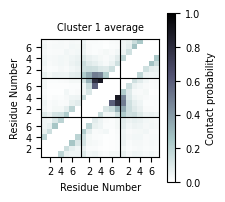

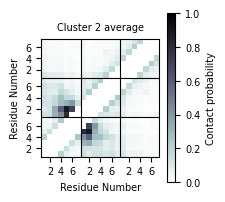

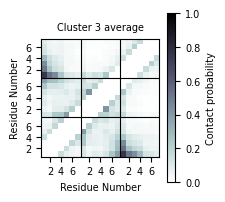

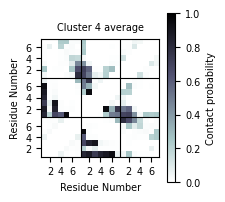

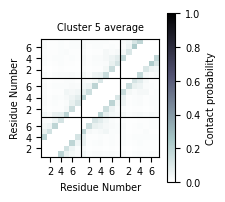

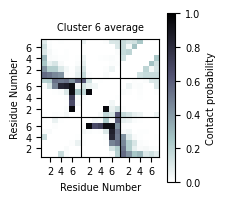

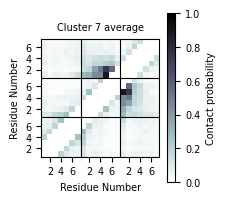

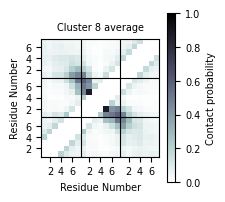

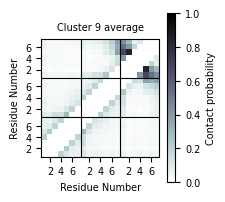

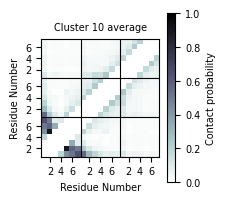

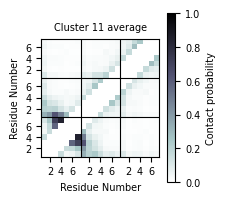

In [25]:
cluster_maps = kmeans.cluster_centers_.reshape((k, 23, 23))
 
for i, cluster_map in enumerate(cluster_maps):
    plt.figure(figsize=(3,3))
    plt.imshow(cluster_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
    plt.title(f"Cluster {i+1} average", fontsize=7)
    plt.xlabel("Residue Number", fontsize=7)
    plt.ylabel("Residue Number", fontsize=7)
    cbar = plt.colorbar(label='Contact probability') #set to 1

    cbar.ax.tick_params(labelsize=7)
    cbar.set_label('Contact probability', size=7)
    
    plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
    plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
    plt.xlim([0.5, 21.5])
    plt.ylim([0.5, 21.5])

    plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
    plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

    plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
    plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)
    
    plt.tight_layout()

    # Get the current figure
    fig = plt.gcf()
    
    # Get the current dimensions
    current_width, current_height = fig.get_size_inches()
    #print(f"Current dimensions: {current_width} x {current_height} inches")
    
    # Define the new width
    new_width = 2
    
    # Calculate the new height to maintain the aspect ratio
    aspect_ratio = current_height / current_width
    new_height = new_width * aspect_ratio
    #print(f"New dimensions: {new_width} x {new_height} inches")
    
    # Set the new figure size
    fig.set_size_inches(new_width, new_height)
    
    # Save the figure
    plt.savefig('cluster_figs/CTD_cluster_' + str(i+1) + '_of_' + str(k) 
                + '_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')
plt.show()

# find centroids and plot

In [26]:
s_time = time.time()

distances = kmeans.transform(all_contact_arrays_1D)
frame_idxs = np.argmin(distances, axis=0)
print("Index of representative frame per cluster:")
for j, idx in enumerate(frame_idxs):
    print(f" Cluster {j}: sample index = {idx}, distance = {distances[idx,j]}")
print("Index in simulation:")

with open('centroid_frames_' + str(k)  + '_clusters_every_' + str(stride) +  '.txt', 'w') as f:

    for j, idx in enumerate(frame_idxs):
        contstruc = ""
        sim = 0
        simoffive = 0
        frame = 0
        add_frames = 0
        if idx < asn_num:
            construct = "ps5n7"
            sim = int(idx/asn_len)+1
            frame = idx-((sim-1)*asn_len)
            if sim > 5:
                starter = 'trans'
                simoffive = sim - 5
            else:
                simoffive = sim
                starter = 'cis'
            trajectory = md.load_netcdf("/data/chem_shared/CTD/" + construct + "/mdcrd/" + construct + 
                                        "_" + starter + "_combined_sim" + str(simoffive) + ".mdcrd",
                                           top="/data/chem_shared/CTD/" + construct + "/" + construct + "_" + starter + "_gas.prmtop")
            add_frames = trajectory.n_frames - asn_sim_frames_total
        elif idx < 2*asn_num:
            construct = "s5n7"
            sim = int((idx-asn_num)/asn_len)+1
            frame = idx-(asn_num)-((sim-1)*asn_len)
            if sim > 5:
                starter = 'trans'
                simoffive = sim - 5
            else:
                simoffive = sim
                starter = 'cis'
            trajectory = md.load_netcdf("/data/chem_shared/CTD/" + construct + "/mdcrd/" + construct + 
                                        "_" + starter + "_combined_sim" + str(simoffive) + ".mdcrd",
                                           top="/data/chem_shared/CTD/" + construct + "/" + construct + "_" + starter + "_gas.prmtop")
            add_frames = trajectory.n_frames - asn_sim_frames_total
        elif idx < 2*asn_num+con_num:
            construct = "ps5s7"
            sim = int((idx-(2*asn_num))/con_len)+1
            frame = idx-(2*asn_num)-((sim-1)*con_len)
            if sim > 5:
                starter = 'trans'
                simoffive = sim - 5
            else:
                simoffive = sim
                starter = 'cis'
            trajectory = md.load_netcdf("/data/chem_shared/CTD/" + construct + "/mdcrd/" + construct + 
                                        "_" + starter + "_combined_sim" + str(simoffive) + ".mdcrd",
                                           top="/data/chem_shared/CTD/" + construct + "/" + construct + "_" + starter + "_gas.prmtop")
            add_frames = trajectory.n_frames - con_sim_frames_total
        elif idx < 2*asn_num+2*con_num:
            construct = "s5s7"
            sim = int((idx-(2*asn_num+con_num))/con_len)+1
            frame = idx-(2*asn_num+con_num)-((sim-1)*con_len)
            if sim > 5:
                starter = 'trans'
                simoffive = sim - 5
            else:
                simoffive = sim
                starter = 'cis'
            trajectory = md.load_netcdf("/data/chem_shared/CTD/" + construct + "/mdcrd/" + construct + 
                                        "_" + starter + "_combined_sim" + str(simoffive) + ".mdcrd",
                                           top="/data/chem_shared/CTD/" + construct + "/" + construct + "_" + starter + "_gas.prmtop")
            add_frames = trajectory.n_frames - con_sim_frames_total
        else:
            print("unexpected high index")
        
        print(f" Cluster {j+1}: {construct} sim {sim} frame {int(add_frames + (frame*stride))}")
        print(f" Cluster {j+1}: {construct} sim {sim} frame {int(add_frames + (frame*stride))}", file=f)


e_time = time.time()
e_time - s_time

Index of representative frame per cluster:
 Cluster 0: sample index = 56956, distance = 1.9950989924658986
 Cluster 1: sample index = 549401, distance = 2.1853796974539623
 Cluster 2: sample index = 232688, distance = 2.6847524987945106
 Cluster 3: sample index = 1406143, distance = 2.524669389519157
 Cluster 4: sample index = 9707, distance = 1.1218262245920692
 Cluster 5: sample index = 1268392, distance = 2.8498551473235993
 Cluster 6: sample index = 99074, distance = 2.282932740324984
 Cluster 7: sample index = 142444, distance = 2.588017731006727
 Cluster 8: sample index = 196752, distance = 2.2498894260657245
 Cluster 9: sample index = 1176716, distance = 2.4360931803026173
 Cluster 10: sample index = 37207, distance = 2.0788271688931887
Index in simulation:
 Cluster 1: ps5n7 sim 2 frame 795600
 Cluster 2: s5n7 sim 2 frame 1040100
 Cluster 3: ps5n7 sim 5 frame 3668800
 Cluster 4: ps5s7 sim 9 frame 4314300
 Cluster 5: ps5n7 sim 1 frame 970700
 Cluster 6: ps5s7 sim 7 frame 139200
 

305.8442335128784

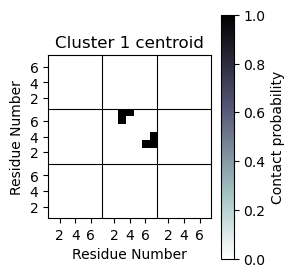

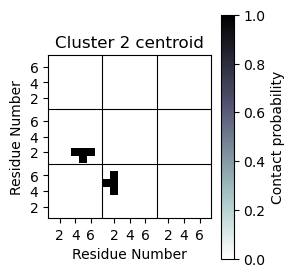

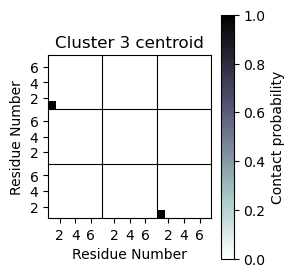

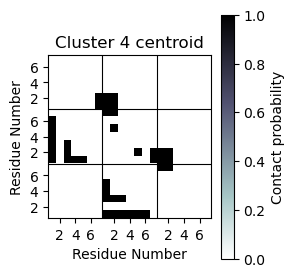

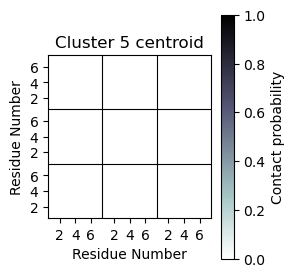

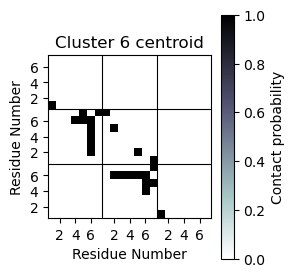

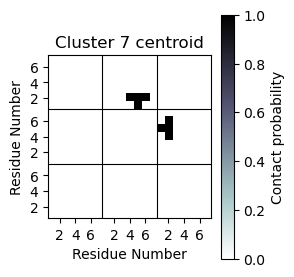

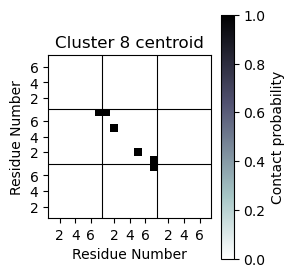

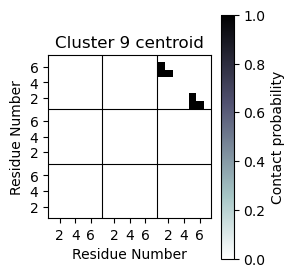

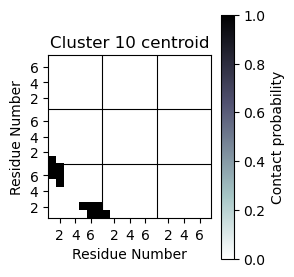

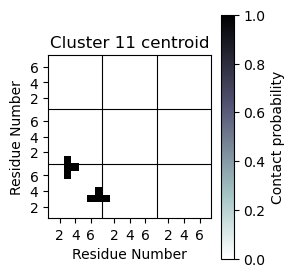

In [28]:
for j, idx in enumerate(frame_idxs):
    centroid_map = all_contact_arrays[idx]
    plt.figure(figsize=(3,3))
    plt.imshow(centroid_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
    plt.title(f"Cluster {j+1} centroid")
    plt.xlabel("Residue Number")
    plt.ylabel("Residue Number")
    plt.colorbar(label='Contact probability') #set to 1

    plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
    plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
    plt.xlim([0.5, 21.5])
    plt.ylim([0.5, 21.5])

    plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
    plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

    plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
    plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)
    
    plt.tight_layout()
    #plt.savefig('/data/kball/CTD/contact_map_clustering/figures/CTD_cluster_centroid_' + str(j+1) + '_of_' + str(k) 
       #         + '_every_' + str(stride) + '.pdf', dpi = 1000)
plt.show()

# Find cluster populations

In [29]:
# read in frame weights
pa_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
a_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
pc_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
c_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [30]:
c_weights_combined_raw

,0
0,5.793364e+19
1,2.327706e+19
2,4.665003e+19
3,1.329841e+20
4,3.049363e+19
...,...
47999995,5.214411e+19
47999996,3.478221e+19
47999997,3.192128e+19
47999998,1.489452e+19


In [31]:
# select out stride
pa_weights_stride = pa_weights_combined_raw.iloc[::stride]
a_weights_stride = a_weights_combined_raw.iloc[::stride]
pc_weights_stride = pc_weights_combined_raw.iloc[::stride]
c_weights_stride = c_weights_combined_raw.iloc[::stride]

In [32]:
pa_weights_stride

,0
0,9.103883e+19
100,1.822134e+19
200,3.327332e+19
300,2.006065e+19
400,1.114158e+20
...,...
48999500,3.914873e+19
48999600,3.433558e+19
48999700,5.623902e+19
48999800,6.578407e+19


In [33]:
# normalize the weights
pa_weights_combined = pa_weights_stride/pa_weights_stride.sum()
a_weights_combined = a_weights_stride/a_weights_stride.sum()
pc_weights_combined = pc_weights_stride/pc_weights_stride.sum()
c_weights_combined = c_weights_stride/c_weights_stride.sum()

In [34]:
# put the cluster labels in a new column
pa_weights_combined['label'] = pa_clust_labels
a_weights_combined['label'] = a_clust_labels
pc_weights_combined['label'] = pc_clust_labels
c_weights_combined['label'] = c_clust_labels

In [35]:
# get cluster weights before reweighting
pa_values, pa_counts = np.unique(pa_clust_labels, return_counts=True)
pa_unweighted_grouped = pd.DataFrame(columns=['labels', 'fraction'])
pa_unweighted_grouped['labels'] = pa_values
pa_unweighted_grouped['fraction'] = pa_counts/pa_counts.sum()

a_values, a_counts = np.unique(a_clust_labels, return_counts=True)
a_unweighted_grouped = pd.DataFrame(columns=['labels', 'fraction'])
a_unweighted_grouped['labels'] = a_values
a_unweighted_grouped['fraction'] = a_counts/a_counts.sum()

pc_values, pc_counts = np.unique(pc_clust_labels, return_counts=True)
pc_unweighted_grouped = pd.DataFrame(columns=['labels', 'fraction'])
pc_unweighted_grouped['labels'] = pc_values
pc_unweighted_grouped['fraction'] = pc_counts/pc_counts.sum()

c_values, c_counts = np.unique(c_clust_labels, return_counts=True)
c_unweighted_grouped = pd.DataFrame(columns=['labels', 'fraction'])
c_unweighted_grouped['labels'] = c_values
c_unweighted_grouped['fraction'] = c_counts/c_counts.sum()

pa_unweighted_grouped

,labels,fraction
0,1,0.173547
1,2,0.082496
2,3,0.037712
3,4,0.003449
4,5,0.282865
5,6,0.002131
6,7,0.054271
7,8,0.057729
8,9,0.058798
9,10,0.076543


non-reweighted cluster populations

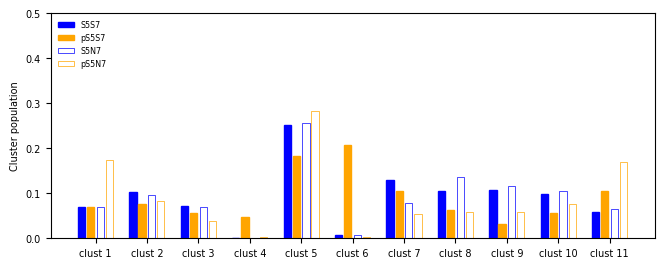

In [36]:
# non-reweighted cluster populations
x = []
for cluster in range(0,k):
    x.append("clust " + str(cluster+1))

x_axis = np.arange(len(x))*1.7

plt.figure(figsize=(10,4))
plt.bar(x_axis - 0.46, c_unweighted_grouped['fraction'], 0.24, label='S5S7', facecolor='blue', edgecolor='blue')
plt.bar(x_axis - 0.16, pc_unweighted_grouped['fraction'], 0.24, label='pS5S7', facecolor='orange', edgecolor='orange')
plt.bar(x_axis + 0.16, a_unweighted_grouped['fraction'], 0.24, linewidth=0.5, label='S5N7', facecolor="None", edgecolor='blue')
plt.bar(x_axis + 0.46, pa_unweighted_grouped['fraction'], 0.24, linewidth=0.5, label='pS5N7', facecolor="None", edgecolor='orange')
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("Cluster population", fontsize = 7)
plt.ylim(top=0.5)  
plt.ylim(bottom=0)
plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/CTD_cluster_unweighted_populations_' + str(k) 
     #       + '_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 6.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.savefig('cluster_figs/CTD_cluster_unweighted_populations_' + str(k) 
            + '_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')

plt.show()

In [37]:
# get the weight of each cluster
with open('cluster_weights_' + str(k)  + '_clusters_every_' + str(stride) +  '.txt', 'w') as f:
    print("pS5N7 cluster weights", file=f)
    pa_weights_grouped = pa_weights_combined.groupby('label')[0].sum()
    print(pa_weights_grouped, file=f)
    print("S5N7 cluster weights", file=f)
    a_weights_grouped = a_weights_combined.groupby('label')[0].sum()
    print(a_weights_grouped, file=f)
    print("pS5S7 cluster weights", file=f)
    pc_weights_grouped = pc_weights_combined.groupby('label')[0].sum()
    print(pc_weights_grouped, file=f)
    print("S5S7 cluster weights", file=f)
    c_weights_grouped = c_weights_combined.groupby('label')[0].sum()
    print(c_weights_grouped, file=f)

In [38]:
with open('cluster_weights_' + str(k)  + '_clusters_every_' + str(stride) +  '.txt', 'r') as f:
    content = f.read()
    print(content)

pS5N7 cluster weights
label
1     0.171749
2     0.083194
3     0.037661
4     0.003370
5     0.287197
6     0.002038
7     0.055040
8     0.057386
9     0.057851
10    0.075842
11    0.168672
Name: 0, dtype: float64
S5N7 cluster weights
label
1     0.068173
2     0.096199
3     0.069242
4     0.001360
5     0.258832
6     0.006740
7     0.078307
8     0.134076
9     0.117038
10    0.104776
11    0.065258
Name: 0, dtype: float64
pS5S7 cluster weights
label
1     0.129250
2     0.102011
3     0.045435
4     0.000536
5     0.266161
6     0.000640
7     0.117789
8     0.019926
9     0.039840
10    0.097901
11    0.180510
Name: 0, dtype: float64
S5S7 cluster weights
label
1     0.068589
2     0.101240
3     0.071223
4     0.000977
5     0.254794
6     0.007788
7     0.130385
8     0.101629
9     0.106491
10    0.098884
11    0.058001
Name: 0, dtype: float64



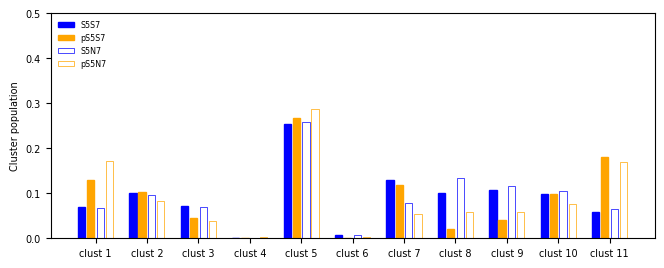

In [39]:
x = []
for cluster in range(0,k):
    x.append("clust " + str(cluster+1))

x_axis = np.arange(len(x))*1.7

plt.figure(figsize=(10,4))
plt.bar(x_axis - 0.46, c_weights_grouped, 0.24, label='S5S7', facecolor='blue', edgecolor='blue')
plt.bar(x_axis - 0.16, pc_weights_grouped, 0.24, label='pS5S7', facecolor='orange', edgecolor='orange')
plt.bar(x_axis + 0.16, a_weights_grouped, 0.24, label='S5N7', linewidth=0.5, facecolor="None", edgecolor='blue')
plt.bar(x_axis + 0.46, pa_weights_grouped, 0.24, label='pS5N7', linewidth=0.5, facecolor="None", edgecolor='orange')
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("Cluster population", fontsize = 7)
plt.ylim(top=0.5)  
plt.ylim(bottom=0)
plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/CTD_cluster_populations_' + str(k) 
    #        + '_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 6.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

plt.savefig('cluster_figs/CTD_cluster_populations_' + str(k) 
            + '_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')

plt.show()